# Ensemble Techniques: Bagging and Boosting

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand ensemble methods (Bagging, Boosting)
- Experiment with ensemble techniques to improve model performance
- Compare bagging vs boosting approaches
- Apply ensemble methods to classification problems

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 3, lesson 02 "Decision Trees and Random Forest" — one tree overfits; bagging and boosting are two ways of combining many.

**Used later in:** Course 04 — Unit 5, lesson 02, which tunes gradient boosting properly.

---

This notebook covers practical activities from **Course 04, Unit 3**:
- Experimenting with ensemble techniques (Bagging, Boosting) to improve prediction accuracy

---

## Introduction to Ensemble Methods

**Ensemble methods** combine multiple models to improve performance:
- **Bagging**: Parallel training, reduces variance (e.g., Random Forest)
- **Boosting**: Sequential training, reduces bias (e.g., AdaBoost, Gradient Boosting)


## 🌍 A real case: the $1,000,000 ensemble Netflix never shipped

In 2006 Netflix offered one million dollars to anyone who could improve its rating predictor by 10%.
The prize was won in 2009 by BellKor's Pragmatic Chaos, whose solution blended **hundreds** of
models — the earlier Progress Prize team alone reported over 2,000 hours of work producing a
combination of 107 algorithms.

Netflix put two of the component algorithms into production and **did not implement the winning
ensemble at all**. Its engineering blog ("Netflix Recommendations: Beyond the 5 stars", April 2012)
gave the reason plainly: the extra accuracy measured offline did not justify the engineering effort
required to run it.

**❗ Why this lesson exists.** An ensemble almost always wins the leaderboard. That is a different
question from whether it deserves to be deployed — and the numbers below set up exactly that argument
on real medical data.

**The data.** 569 fine-needle-aspirate biopsies from the University of Wisconsin, 30 features computed
from digitised images of cell nuclei (Street, Wolberg & Mangasarian, 1993), 212 malignant and 357
benign. The test set is **114 patients**, which is the number to keep in mind when reading any gap
below.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- The real Breast Cancer Wisconsin (Diagnostic) dataset bundled with scikit-learn:
  569 biopsies described by 30 measurements, labelled malignant or benign — no download

**Outputs:** What you'll see when you run the cells

- Held-out accuracy for one decision tree and for three ensembles built from trees,
  plus the gap between each ensemble and the single tree it is made of.

---

In [1]:
# CELL: Import a single tree plus three ways of combining many trees.
# WHY: the whole lesson is one experiment - does a TEAM of weak models
# (bagging, AdaBoost, gradient boosting) beat one tree working alone?
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt   # this lesson's claims are comparisons - they need pictures

In [2]:
# Load a REAL diagnostic dataset: 569 breast-tumour biopsies (Wisconsin Diagnostic, UCI),
# each described by 30 measurements taken from a digitized image of the cell nuclei.
# WHY this one: the classes genuinely overlap, so a single tree has real errors to fix —
# which is the only way an ensemble can show what it is worth.
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target        # 0 = malignant, 1 = benign

# stratify=y keeps the malignant/benign ratio identical in both halves of the split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Real dataset: {X.shape[0]} biopsies x {X.shape[1]} measurements")
print(f"Classes: {np.bincount(y)} (malignant, benign)")
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Always-predict-'benign' baseline on the test set: {(y_test == 1).mean():.4f}")

Real dataset: 569 biopsies x 30 measurements
Classes: [212 357] (malignant, benign)
Training set: (455, 30), Test set: (114, 30)
Always-predict-'benign' baseline on the test set: 0.6316


## Part 1: Base Model (Single Decision Tree)


In [3]:
# Base model: a single decision tree (our reference point)
base_tree = DecisionTreeClassifier(random_state=42)
base_tree.fit(X_train, y_train)
base_pred = base_tree.predict(X_test)
base_acc = accuracy_score(y_test, base_pred)

print(f"Single Decision Tree accuracy: {base_acc:.4f}")
print(f"  ...on the TRAINING data it scores {base_tree.score(X_train, y_train):.4f} —")
print("  an unpruned tree can always memorize its training set. The gap between those")
print("  two numbers is the variance the ensembles below are going to attack.")

Single Decision Tree accuracy: 0.9123
  ...on the TRAINING data it scores 1.0000 —
  an unpruned tree can always memorize its training set. The gap between those
  two numbers is the variance the ensembles below are going to attack.


## Part 2: Bagging (Random Forest is a type of Bagging)


In [4]:
# Bagging Classifier: many trees trained in parallel on bootstrap samples
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                            random_state=42)
bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)
bagging_acc = accuracy_score(y_test, bagging_pred)

print(f"Bagging (100 trees) accuracy:  {bagging_acc:.4f}")
print(f"Improvement over single tree:  {bagging_acc - base_acc:+.4f}")

Bagging (100 trees) accuracy:  0.9386
Improvement over single tree:  +0.0263


## Part 3: Boosting Methods


In [5]:
# AdaBoost: trees trained sequentially, each focusing on previous errors
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost.fit(X_train, y_train)
adaboost_pred = adaboost.predict(X_test)
adaboost_acc = accuracy_score(y_test, adaboost_pred)

# Gradient Boosting: boosting with gradient-based error correction
gboost = GradientBoostingClassifier(n_estimators=100, random_state=42)
gboost.fit(X_train, y_train)
gboost_pred = gboost.predict(X_test)
gboost_acc = accuracy_score(y_test, gboost_pred)

print("Final comparison (test accuracy):")
print("-" * 44)
print(f"  Single Decision Tree: {base_acc:.4f}")
print(f"  Bagging (100 trees):  {bagging_acc:.4f}")
print(f"  AdaBoost (100):       {adaboost_acc:.4f}")
print(f"  Gradient Boosting:    {gboost_acc:.4f}")
print()
print(f"  (Always predicting 'benign' would score {(y_test == 1).mean():.4f})")
print()
print("All three ensembles beat the single tree on this data. Bagging attacks the")
print("tree's VARIANCE by averaging 100 trees grown on bootstrap resamples; the two")
print("boosting methods attack its BIAS by training each tree on what the previous")
print("ones got wrong. Which family wins depends on the dataset - here boosting edges")
print("ahead, but the margin is a handful of biopsies out of 114, so do not read a")
print("universal law into it.")

Final comparison (test accuracy):
--------------------------------------------
  Single Decision Tree: 0.9123
  Bagging (100 trees):  0.9386
  AdaBoost (100):       0.9561
  Gradient Boosting:    0.9561

  (Always predicting 'benign' would score 0.6316)

All three ensembles beat the single tree on this data. Bagging attacks the
tree's VARIANCE by averaging 100 trees grown on bootstrap resamples; the two
boosting methods attack its BIAS by training each tree on what the previous
ones got wrong. Which family wins depends on the dataset - here boosting edges
ahead, but the margin is a handful of biopsies out of 114, so do not read a
universal law into it.


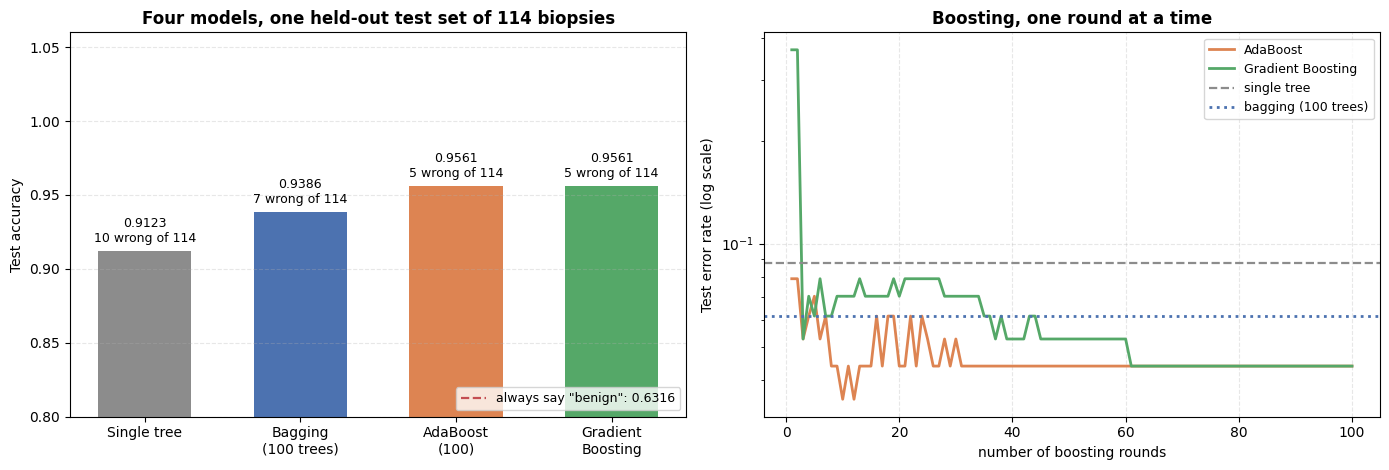


📊 Step table: test error as boosting rounds accumulate
  rounds   AdaBoost errors   GradBoost errors
----------------------------------------------
       1                 9                 42
       2                 9                 42
       5                 8                  7
      10                 4                  8
      25                 6                  9
      50                 5                  6
     100                 5                  5

 For reference: single tree 10 wrong, bagging 7 wrong, out of 114.
 Differences of one or two biopsies are noise, not a ranking of algorithms.


In [6]:
# CELL: Draw the comparison the four print statements above only list.
# WHY: the text warns that the winning margin is "a handful of biopsies out of
# 114". A bar chart of accuracies hides that; a bar chart labelled with the
# actual ERROR COUNT makes it impossible to overclaim.

n_test = len(y_test)
model_names = ['Single tree', 'Bagging\n(100 trees)', 'AdaBoost\n(100)',
               'Gradient\nBoosting']
accs = [base_acc, bagging_acc, adaboost_acc, gboost_acc]
errors = [int(round((1 - a) * n_test)) for a in accs]
baseline = (y_test == 1).mean()          # always predict "benign"

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# --- Panel 1: who wins, and by how many biopsies
ax = axes[0]
bars = ax.bar(model_names, accs,
              color=['#8C8C8C', '#4C72B0', '#DD8452', '#55A868'], width=0.6)
for b, a, e in zip(bars, accs, errors):
    ax.text(b.get_x() + b.get_width() / 2, a + 0.006,
            f"{a:.4f}\n{e} wrong of {n_test}", ha='center', fontsize=9)
ax.axhline(baseline, color='#C44E52', linestyle='--', linewidth=1.6,
           label=f'always say "benign": {baseline:.4f}')
ax.set_ylim(0.80, 1.06)
ax.set_ylabel('Test accuracy')
ax.set_title('Four models, one held-out test set of 114 biopsies',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# --- Panel 2: how the two boosting models got there, round by round.
# staged_predict replays the ensemble after 1 tree, 2 trees, ... 100 trees.
ada_err = [1 - accuracy_score(y_test, p) for p in adaboost.staged_predict(X_test)]
gb_err = [1 - accuracy_score(y_test, p) for p in gboost.staged_predict(X_test)]
rounds = np.arange(1, len(ada_err) + 1)

ax = axes[1]
ax.plot(rounds, ada_err, color='#DD8452', linewidth=2, label='AdaBoost')
ax.plot(rounds[:len(gb_err)], gb_err, color='#55A868', linewidth=2,
        label='Gradient Boosting')
ax.axhline(1 - base_acc, color='#8C8C8C', linestyle='--', linewidth=1.6,
           label='single tree')
ax.axhline(1 - bagging_acc, color='#4C72B0', linestyle=':', linewidth=2,
           label='bagging (100 trees)')
ax.set_xlabel('number of boosting rounds')
ax.set_yscale('log')          # round 1 of gradient boosting is 10x the rest
ax.set_ylabel('Test error rate (log scale)')
ax.set_title('Boosting, one round at a time', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')

fig.tight_layout()
plt.show()

print("\n📊 Step table: test error as boosting rounds accumulate")
print(f"{'rounds':>8} {'AdaBoost errors':>17} {'GradBoost errors':>18}")
print("-" * 46)
for n in [1, 2, 5, 10, 25, 50, 100]:
    if n <= len(ada_err):
        print(f"{n:>8d} {round(ada_err[n-1]*n_test):>17d} "
              f"{round(gb_err[n-1]*n_test):>18d}")
print(f"\n For reference: single tree {errors[0]} wrong, bagging {errors[1]} wrong, "
      f"out of {n_test}.")
print(" Differences of one or two biopsies are noise, not a ranking of algorithms.")


**Read the figure.** Left, the four models on one axis with the red dashed line marking what you would score by saying "benign" every time — every bar clears it, which is the minimum bar any medical classifier must clear. Now read the second line of each label, the raw error count: single tree 10 wrong, bagging 7, both boosters 5, out of 114. The bars look decisive; the counts say be careful — AdaBoost and Gradient Boosting are *tied*, and the whole gap to bagging is two biopsies.

Right, where those numbers came from, on a log axis because gradient boosting's first round is an order of magnitude worse than everything after it. Two things deserve a pause. The green curve starts far above the grey single-tree line and dives under it within about three rounds. The orange one never needs to: AdaBoost's very first stump — one cut, on one measurement — is already better than the fully grown tree, which tells you how much of that tree's depth was memorisation rather than signal. By round 60 neither curve moves again; past that point extra estimators buy compute, not accuracy.

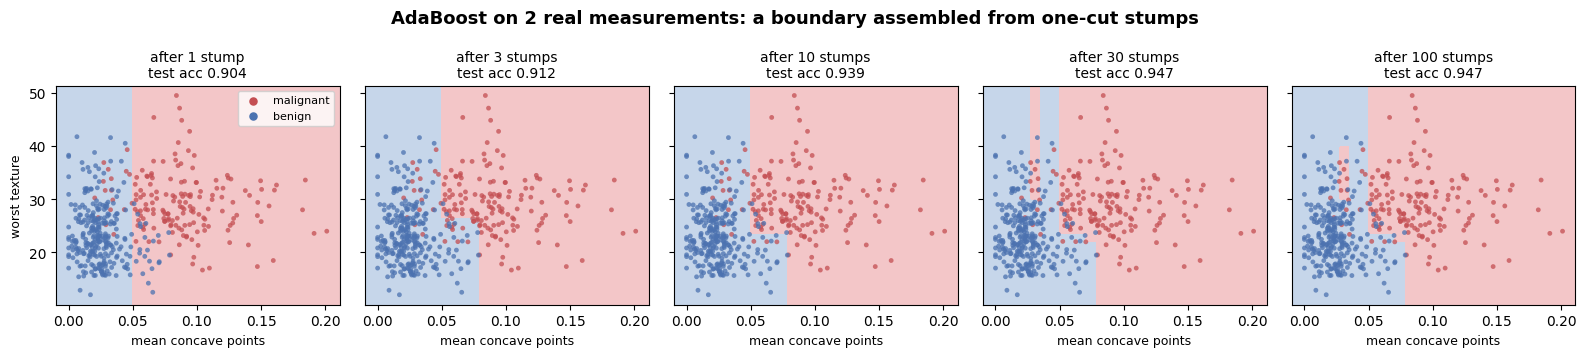


📊 Step table behind the storyboard (2-feature view, 114 test biopsies):
  stumps   test accuracy   test errors
---------------------------------------
       1          0.9035            11
       3          0.9123            10
      10          0.9386             7
      30          0.9474             6
     100          0.9474             6

💡 Every edge you see is horizontal or vertical: a stump can only cut on
   one feature at one value. The staircase is what 100 of them add up to.


In [7]:
# CELL: Storyboard - watch AdaBoost build a boundary out of stumps.
# WHY: the curve above shows the error falling; it cannot show WHAT is being
# built. AdaBoost's base learner is a depth-1 tree - a single straight cut. Any
# corner in the final boundary is made entirely of stacked straight cuts.
# We use 2 of the 30 real measurements so the boundary can be drawn at all.
import matplotlib.colors as mpl_colors
fi, fj = 7, 21   # 'mean concave points' and 'worst texture' - two different
                 # measurement families, so stumps must alternate between axes
X2_train = X_train[:, [fi, fj]]
X2_test = X_test[:, [fi, fj]]
ada2 = AdaBoostClassifier(n_estimators=100, random_state=42).fit(X2_train, y_train)

# pad each axis by 5%% of ITS OWN range - the two measurements are on wildly
# different scales (concave points ~0-0.2, texture ~10-50)
p0 = 0.05 * np.ptp(X2_train[:, 0])
p1 = 0.05 * np.ptp(X2_train[:, 1])
gx = np.linspace(X2_train[:, 0].min() - p0, X2_train[:, 0].max() + p0, 130)
gy = np.linspace(X2_train[:, 1].min() - p1, X2_train[:, 1].max() + p1, 130)
GX, GY = np.meshgrid(gx, gy)
mesh = np.c_[GX.ravel(), GY.ravel()]

frame_rounds = [1, 3, 10, 30, 100]
# region colours MATCHED to the point colours below, so the shading and the
# dots never disagree about which side is malignant
region_cmap = mpl_colors.ListedColormap(['#F3C6C8', '#C6D6EA'])
# One pass over the stages: keep only the frames we want to draw, plus the
# test-set score at each of those rounds.
mesh_frames, test_acc_at = {}, {}
for r, (pm, pt) in enumerate(zip(ada2.staged_predict(mesh),
                                 ada2.staged_predict(X2_test)), start=1):
    if r in frame_rounds:
        mesh_frames[r] = pm.reshape(GX.shape)
        test_acc_at[r] = accuracy_score(y_test, pt)

fig, axes = plt.subplots(1, len(frame_rounds), figsize=(16, 3.6), sharey=True,
                         sharex=True)
for ax, r in zip(axes, frame_rounds):
    ax.contourf(GX, GY, mesh_frames[r], cmap=region_cmap,
                levels=[-0.5, 0.5, 1.5])
    ax.scatter(X2_train[y_train == 0, 0], X2_train[y_train == 0, 1], s=12,
               c='#C44E52', edgecolors='none', alpha=0.75)
    ax.scatter(X2_train[y_train == 1, 0], X2_train[y_train == 1, 1], s=12,
               c='#4C72B0', edgecolors='none', alpha=0.75)
    ax.set_title(f"after {r} stump{'s' if r > 1 else ''}\n"
                 f"test acc {test_acc_at[r]:.3f}", fontsize=10)
    ax.set_xlabel(cancer.feature_names[fi], fontsize=9)
axes[0].set_ylabel(cancer.feature_names[fj], fontsize=9)
axes[0].scatter([], [], c='#C44E52', s=26, label='malignant')
axes[0].scatter([], [], c='#4C72B0', s=26, label='benign')
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('AdaBoost on 2 real measurements: a boundary assembled from '
             'one-cut stumps', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print("\n📊 Step table behind the storyboard (2-feature view, 114 test biopsies):")
print(f"{'stumps':>8} {'test accuracy':>15} {'test errors':>13}")
print("-" * 39)
for r in frame_rounds:
    print(f"{r:>8d} {test_acc_at[r]:>15.4f} "
          f"{round((1 - test_acc_at[r]) * len(y_test)):>13d}")
print("\n💡 Every edge you see is horizontal or vertical: a stump can only cut on")
print("   one feature at one value. The staircase is what 100 of them add up to.")


**Read the storyboard.** Frame 1 is a single stump: one vertical cut on `mean concave points`, the whole plane split in two. That is the "weak learner" boosting starts from. Frame 3 is still one cut, just moved. By frame 10 a *horizontal* cut has joined it — the blue region grows an L-shaped corner reaching right along the bottom, because stumps have started splitting on `worst texture` too. Frames 30 and 100 add thin vertical slivers near the left edge, small pockets carved out for a handful of stubborn points.

Every edge in every frame is horizontal or vertical: a depth-1 tree cannot draw anything else, so this boundary is a staircase, never a curve. The shaded regions use the same two colours as the dots, so a dot on the wrong shade is a mistake you can point at. Finally read the accuracies across the top: they climb while the boundary is acquiring its first real corner, and then stop, while the boundary carries on fiddling at the edges. That is where extra rounds stop buying skill.

## 💬 Discuss

Printed results: single tree **0.9123** (train 1.0000), Bagging **0.9386**, AdaBoost **0.9561**,
Gradient Boosting **0.9561**; always-predict-benign **0.6316**; test set 114 biopsies.

1. **AdaBoost and Gradient Boosting tie at 0.9561 and beat Bagging's 0.9386 by 2.5 points — which on
   114 patients is about two biopsies.** Is "boosting beats bagging" a finding here, or a
   coincidence? Name the experiment that would settle it, then decide whether it is worth running.

2. **The single tree scores 0.9123 and fits on one page; the ensembles score ~0.95 and do not.**
   For a pathology screening tool, does roughly 4 points buy enough to give up the explanation?
   Netflix decided the *opposite* way about a 10% gain. What is different about the two situations —
   and is any of the difference about the size of the number?

3. **Always predicting "benign" scores 0.6316 on this test set.** Name the one number from the
   malignant class that you would demand before letting any of these models near a clinic, say why
   accuracy is not that number, and state the value of it you would insist on.


## Summary

### Key Concepts:
1. **Bagging**: Trains models in parallel, averages predictions (reduces variance)
2. **Boosting**: Trains models sequentially, focuses on errors (reduces bias)
3. **Ensemble Benefit**: on these 569 real biopsies, every ensemble beat the single tree
4. **When to use**: Bagging for high variance models, Boosting for high bias models

### A caution about small test sets
The test set here is 114 biopsies, so one extra correct prediction moves accuracy by
0.0088. Differences between the three ensembles are within a few such steps of each
other — real, but not a ranking you should carry to another dataset. Unit 5 shows how
cross-validation gives a sturdier comparison.

**Reference:** Course 04, Unit 3: "Experimenting with ensemble techniques (Bagging, Boosting)"


## ⚠️ Where this breaks

- **Boosting chases errors, including the wrong ones.** Each new tree is fitted to what the previous
  ones got wrong, so a mislabelled biopsy gets progressively more weight. On noisy labels AdaBoost
  degrades where bagging simply shrugs — and medical labels are noisier than they look.
- **A hundred trees cost a hundred times the prediction work of one.** Irrelevant here; decisive on a
  device, at line rate, or inside a request that must return in 50 milliseconds.
- **Bagging's gain requires disagreement among the base learners.** See Unit 1's SVR/tree lesson: with
  a single input taking 24 distinct values, averaging 100 trees bought nothing, because every tree
  found the same splits. If your base models already agree, an ensemble of them is just a slower copy.
- **Boosting is sequential by construction**, so it does not parallelise across trees the way a
  random forest does — a real constraint when retraining is on a schedule.
- **The assumption that must hold:** the test set is large enough for the gaps to mean anything.
  Two biopsies out of 114 is not a result; it is a rounding difference between two runs.
- **The cheaper alternative:** when the base model is already stable and the dataset is small, do not
  ensemble. Tune the single model, and spend the effort on getting more or better-labelled data —
  which on this dataset would move the number further than any of the three methods above.


## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

Bagging and boosting are the two ways of turning many weak learners into one strong one, and that
mechanism — variance reduced by averaging, bias reduced by fitting what the previous model got wrong —
is exactly what this unit exists to teach. What moved in 2025–2026 is the *baseline they get measured
against* on small tabular problems of the size used here. Tabular foundation models are pretrained once
on synthetic data and then predict in-context, with no per-dataset training: the authors of TabPFN-2.5
report a 100% win rate against default XGBoost on classification datasets up to 10,000 rows and 500
features (Grinsztajn et al., 2025, arXiv:2511.08667), and TabPFN-3 reports that a single forward pass
outperforms tuned and ensembled baselines on the TabArena benchmark (Grinsztajn et al., 2026,
arXiv:2605.13986). Read both as authors' reported numbers on their own benchmarks rather than as a
verdict — running those models needs downloaded pretrained weights, so this classroom cannot reproduce
them offline. Keep the ensembles: they explain the mechanism, they are the baseline in every one of
those comparisons, they run here on a CPU in seconds, and they are what the official plan examines.

## 📚 References

1. Breiman, L. (1996). *Bagging Predictors*. Machine Learning, 24, 123–140.
2. Freund, Y., & Schapire, R. E. (1997). *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting*. Journal of Computer and System Sciences, 55(1), 119–139.
3. Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD 2016. <https://arxiv.org/abs/1603.02754>
4. Bentéjac, C., Csörgő, A., & Martínez-Muñoz, G. (2021). *A Comparative Analysis of XGBoost* (journal version: Artificial Intelligence Review, 54, 1937–1967). <https://arxiv.org/abs/1911.01914>
5. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. <https://arxiv.org/abs/2511.08667>
6. Grinsztajn, L., Flöge, K., Key, O., et al. (2026). *TabPFN-3: Technical Report*. <https://arxiv.org/abs/2605.13986>
